# Setup

Import libraries dan konfigurasi plotting style.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from transformers import LongformerTokenizerFast
import re
import os

import warnings
warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load Dataset

Memuat dataset training dan menampilkan informasi dasar.

In [23]:
train_path = "./data/train/train.csv"
df = pd.read_csv(train_path)

display(df.head())
df.info()

,Body ID,articleBody,Headline,Stance
0,0,A small meteorite crashed into a wooded area i...,"Soldier shot, Parliament locked down after gun...",unrelated
1,0,A small meteorite crashed into a wooded area i...,Tourist dubbed ‘Spider Man’ after spider burro...,unrelated
2,0,A small meteorite crashed into a wooded area i...,Luke Somers 'killed in failed rescue attempt i...,unrelated
3,0,A small meteorite crashed into a wooded area i...,BREAKING: Soldier shot at War Memorial in Ottawa,unrelated
4,0,A small meteorite crashed into a wooded area i...,Giant 8ft 9in catfish weighing 19 stone caught...,unrelated


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49972 entries, 0 to 49971
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Body ID      49972 non-null  int64 
 1   articleBody  49972 non-null  object
 2   Headline     49972 non-null  object
 3   Stance       49972 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


# Dataset Shape

Jumlah baris dan kolom dalam dataset.

In [24]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 49972
Number of columns: 4


# Dataset Columns

Nama kolom dan tipe data masing-masing.

In [25]:
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Column Names:
['Body ID', 'articleBody', 'Headline', 'Stance']

Data Types:
Body ID         int64
articleBody    object
Headline       object
Stance         object
dtype: object


# Missing Values

Menghitung jumlah missing value per kolom.

In [26]:
df.isnull().sum()

Body ID        0
articleBody    0
Headline       0
Stance         0
dtype: int64

# Duplicate Analysis

Mengecek jumlah baris duplikat dan pasangan headline-body yang duplikat.

In [27]:
exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates}")

if 'Headline' in df.columns and 'Body ID' in df.columns:
    hb_duplicates = df.duplicated(subset=['Headline', 'Body ID']).sum()
    print(f"Duplicate headline-body pairs: {hb_duplicates}")

Exact duplicate rows: 402
Duplicate headline-body pairs: 402


# Label Distribution

Distribusi jumlah dan persentase per label stance.

,Count,Percentage
Stance,,
unrelated,36545,73.130953
discuss,8909,17.827984
agree,3678,7.360122
disagree,840,1.680941


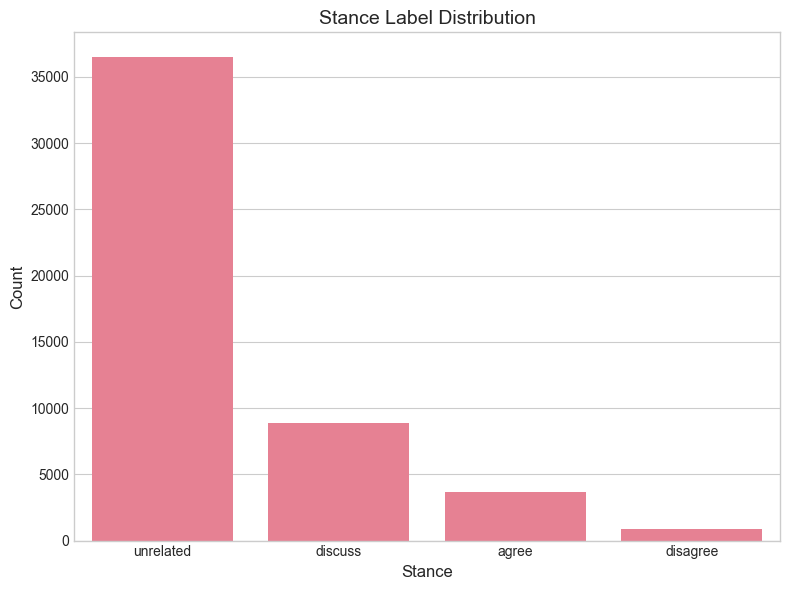

In [28]:
stance_counts = df['Stance'].value_counts()
stance_perc = df['Stance'].value_counts(normalize=True) * 100

label_dist_df = pd.DataFrame({'Count': stance_counts, 'Percentage': stance_perc})
display(label_dist_df)

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Stance', order=stance_counts.index)
plt.title("Stance Label Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Unique Analysis

Jumlah headline unik, Body ID unik, dan Body ID yang paling sering muncul.

In [29]:
unique_headlines = df['Headline'].nunique()
unique_body_ids = df['Body ID'].nunique()

print(f"Unique Headlines: {unique_headlines}")
print(f"Unique Body IDs: {unique_body_ids}")

print("\nMost repeated Body IDs:")
display(df['Body ID'].value_counts().head(10))

Unique Headlines: 1648
Unique Body IDs: 1683

Most repeated Body IDs:


Body ID
1921    187
1948    175
40      172
524     171
1549    166
304     154
1385    151
125     145
2367    143
1438    141
Name: count, dtype: int64

# Headline Length Analysis

Analisis panjang karakter dan jumlah kata pada headline.

Headline Character Length Summary:


count    49972.000000
mean        69.356860
std         24.825253
min          9.000000
25%         54.000000
50%         65.000000
75%         79.000000
max        225.000000
Name: Headline_Char_Length, dtype: float64


Headline Word Count Summary:


count    49972.000000
mean        11.126471
std          4.201797
min          2.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         40.000000
Name: Headline_Word_Count, dtype: float64

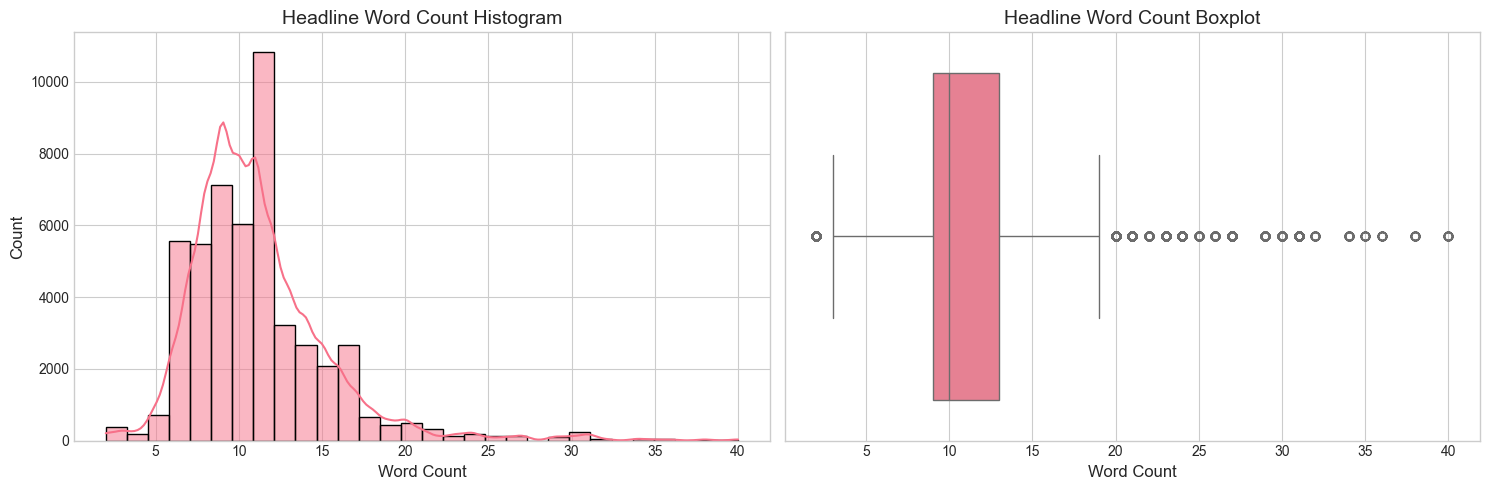

In [30]:
df['Headline_Char_Length'] = df['Headline'].astype(str).apply(len)
df['Headline_Word_Count'] = df['Headline'].astype(str).apply(lambda x: len(x.split()))

print("Headline Character Length Summary:")
display(df['Headline_Char_Length'].describe())

print("\nHeadline Word Count Summary:")
display(df['Headline_Word_Count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Headline_Word_Count'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Headline Word Count Histogram')
axes[0].set_xlabel('Word Count')

sns.boxplot(x=df['Headline_Word_Count'], ax=axes[1])
axes[1].set_title('Headline Word Count Boxplot')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# Article Length Analysis

Analisis panjang karakter dan jumlah kata pada article body.

Article Character Length Summary:


count    49972.000000
mean      2207.547266
std       1676.838550
min         38.000000
25%       1175.000000
50%       1824.000000
75%       2765.000000
max      27579.000000
Name: Article_Char_Length, dtype: float64


Article Word Count Summary:


count    49972.000000
mean       369.701713
std        279.695303
min          4.000000
25%        201.000000
50%        304.000000
75%        461.000000
max       4788.000000
Name: Article_Word_Count, dtype: float64

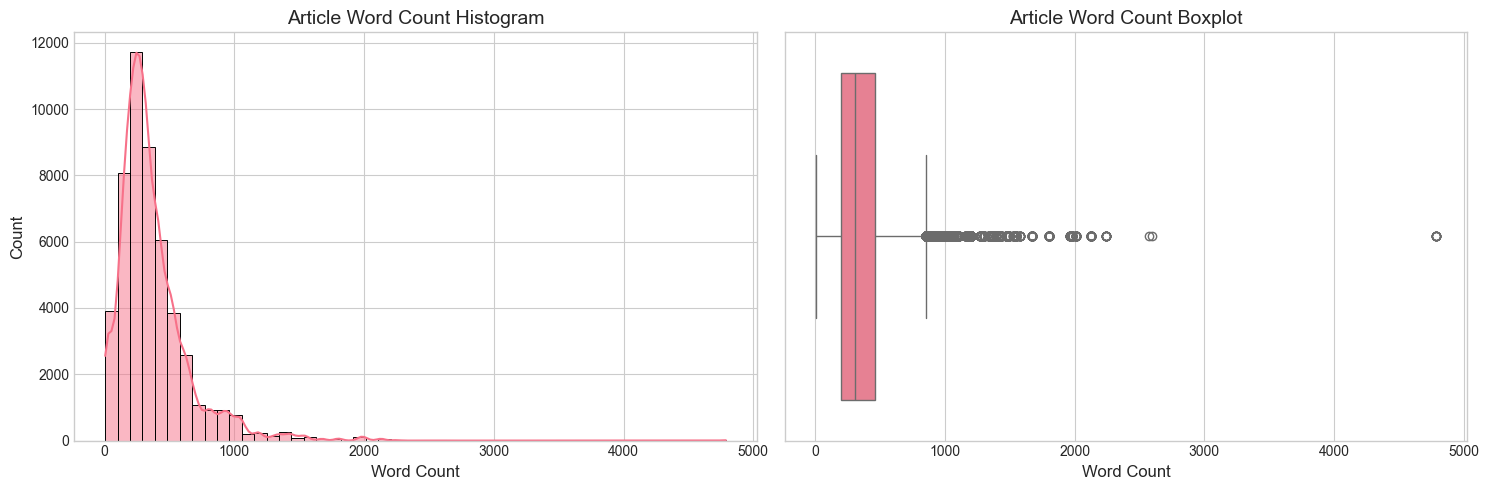

In [31]:
df['Article_Char_Length'] = df['articleBody'].astype(str).apply(len)
df['Article_Word_Count'] = df['articleBody'].astype(str).apply(lambda x: len(x.split()))

print("Article Character Length Summary:")
display(df['Article_Char_Length'].describe())

print("\nArticle Word Count Summary:")
display(df['Article_Word_Count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Article_Word_Count'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Article Word Count Histogram')
axes[0].set_xlabel('Word Count')

sns.boxplot(x=df['Article_Word_Count'], ax=axes[1])
axes[1].set_title('Article Word Count Boxplot')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# Token Length Analysis

Menghitung jumlah token menggunakan LongformerTokenizerFast dari model allenai/longformer-base-4096.

Tokenizing headlines...
Tokenizing articles (this may take a moment)...
--- Headline Token Length Statistics ---
Mean: 15.66
Median: 15.00
Max: 84
95th percentile: 26.00
99th percentile: 36.00
--- Article Token Length Statistics ---
Mean: 496.36
Median: 407.00
Max: 6156
95th percentile: 1240.00
99th percentile: 1891.00


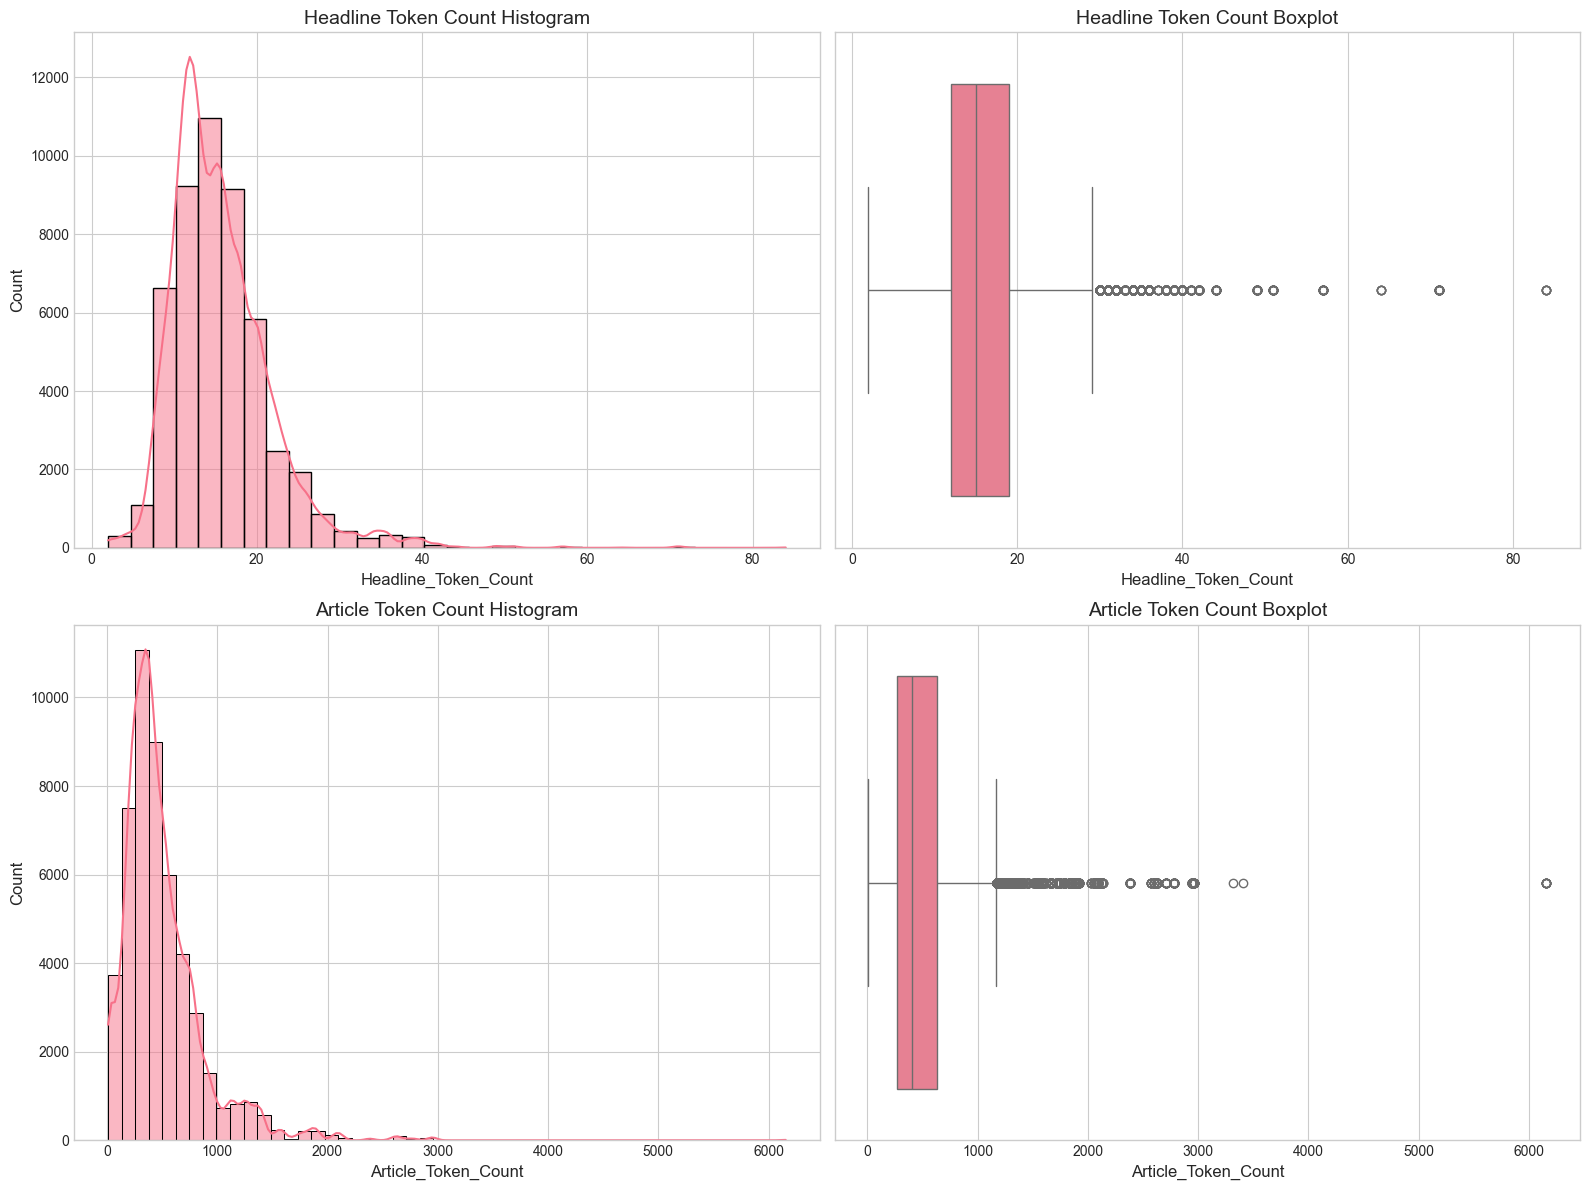

In [32]:
tokenizer = LongformerTokenizerFast.from_pretrained("allenai/longformer-base-4096")

def count_tokens(text):
    return len(tokenizer.encode(str(text), add_special_tokens=False))

print("Tokenizing headlines...")
df['Headline_Token_Count'] = df['Headline'].apply(count_tokens)

print("Tokenizing articles (this may take a moment)...")
df['Article_Token_Count'] = df['articleBody'].apply(count_tokens)

def report_percentiles(series, name):
    print(f"--- {name} Token Length Statistics ---")
    print(f"Mean: {series.mean():.2f}")
    print(f"Median: {series.median():.2f}")
    print(f"Max: {series.max()}")
    print(f"95th percentile: {np.percentile(series, 95):.2f}")
    print(f"99th percentile: {np.percentile(series, 99):.2f}")

report_percentiles(df['Headline_Token_Count'], "Headline")
report_percentiles(df['Article_Token_Count'], "Article")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.histplot(df['Headline_Token_Count'], bins=30, ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Headline Token Count Histogram')

sns.boxplot(x=df['Headline_Token_Count'], ax=axes[0, 1])
axes[0, 1].set_title('Headline Token Count Boxplot')

sns.histplot(df['Article_Token_Count'], bins=50, ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Article Token Count Histogram')

sns.boxplot(x=df['Article_Token_Count'], ax=axes[1, 1])
axes[1, 1].set_title('Article Token Count Boxplot')

plt.tight_layout()
plt.show()

# Longformer Suitability Analysis

Menghitung persentase artikel yang melebihi batas token pada berbagai threshold.

Percentage exceeding BERT limit (512 tokens): 35.72%
Maximum token length: 6156


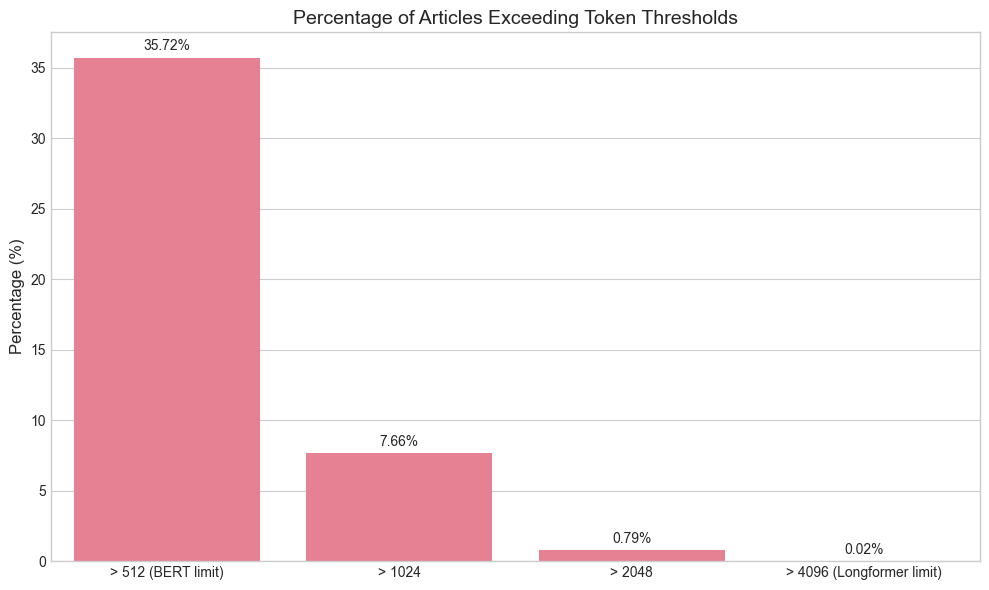

In [33]:
total_samples = len(df)
above_512 = (df['Article_Token_Count'] > 512).sum()
above_1024 = (df['Article_Token_Count'] > 1024).sum()
above_2048 = (df['Article_Token_Count'] > 2048).sum()
above_4096 = (df['Article_Token_Count'] > 4096).sum()

thresholds = {
    '> 512 (BERT limit)': above_512,
    '> 1024': above_1024,
    '> 2048': above_2048,
    '> 4096 (Longformer limit)': above_4096
}

percentages = {k: (v / total_samples) * 100 for k, v in thresholds.items()}

print(f"Percentage exceeding BERT limit (512 tokens): {percentages['> 512 (BERT limit)']:.2f}%")
print(f"Maximum token length: {df['Article_Token_Count'].max()}")

plt.figure(figsize=(10, 6))
sns.barplot(x=list(thresholds.keys()), y=list(percentages.values()))
plt.title("Percentage of Articles Exceeding Token Thresholds")
plt.ylabel("Percentage (%)")
for i, v in enumerate(percentages.values()):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')
plt.tight_layout()
plt.show()

# Token Length By Label

Analisis distribusi jumlah token artikel per kelas stance (agree, disagree, discuss, unrelated).

Mean Token Count per Class:


Stance
agree        468.241979
disagree     506.894048
discuss      536.128185
unrelated    489.247394
Name: Article_Token_Count, dtype: float64


Median Token Count per Class:


Stance
agree        380.0
disagree     420.0
discuss      427.0
unrelated    404.0
Name: Article_Token_Count, dtype: float64

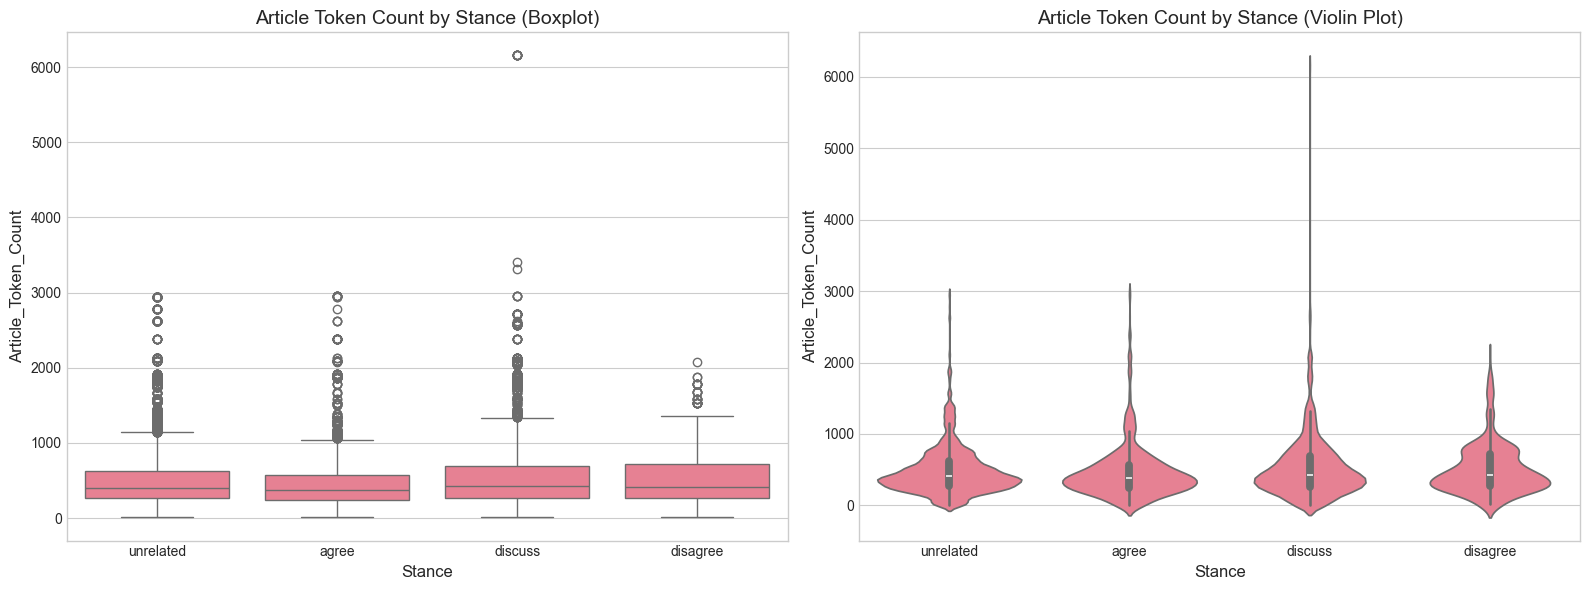

In [34]:
print("Mean Token Count per Class:")
mean_tokens = df.groupby('Stance')['Article_Token_Count'].mean()
display(mean_tokens)

print("\nMedian Token Count per Class:")
median_tokens = df.groupby('Stance')['Article_Token_Count'].median()
display(median_tokens)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Stance', y='Article_Token_Count', ax=axes[0])
axes[0].set_title('Article Token Count by Stance (Boxplot)')

sns.violinplot(data=df, x='Stance', y='Article_Token_Count', ax=axes[1])
axes[1].set_title('Article Token Count by Stance (Violin Plot)')

plt.tight_layout()
plt.show()

# Class Imbalance Analysis

Analisis ketidakseimbangan kelas pada dataset.

Majority class: unrelated (36545 samples)
Minority class: disagree (840 samples)
Imbalance ratio (Majority/Minority): 43.51


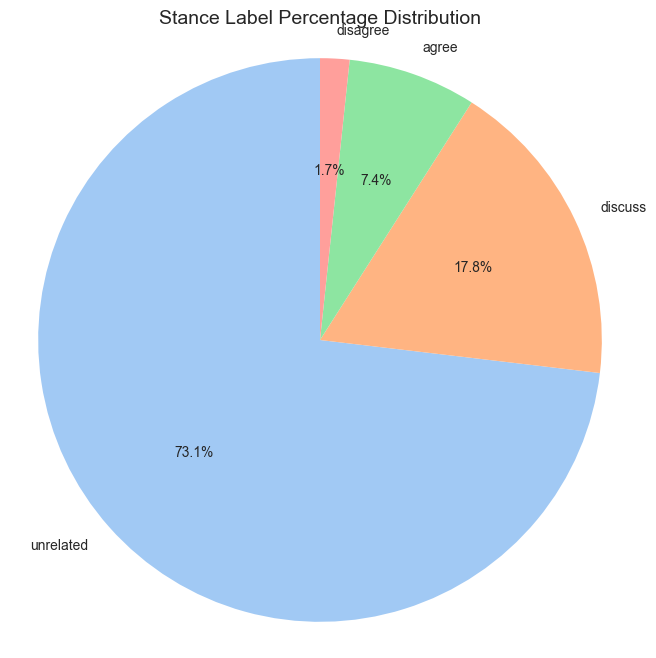

In [35]:
stance_counts = df['Stance'].value_counts()
majority_class = stance_counts.idxmax()
minority_class = stance_counts.idxmin()
imbalance_ratio = stance_counts.max() / stance_counts.min()

print(f"Majority class: {majority_class} ({stance_counts.max()} samples)")
print(f"Minority class: {minority_class} ({stance_counts.min()} samples)")
print(f"Imbalance ratio (Majority/Minority): {imbalance_ratio:.2f}")

plt.figure(figsize=(8, 8))
plt.pie(stance_counts, labels=stance_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title("Stance Label Percentage Distribution")
plt.axis('equal')
plt.show()

# WordCloud Analysis

Word cloud untuk headline, article body, dan masing-masing kelas stance setelah preprocessing (lowercase, punctuation removal, stopword removal).

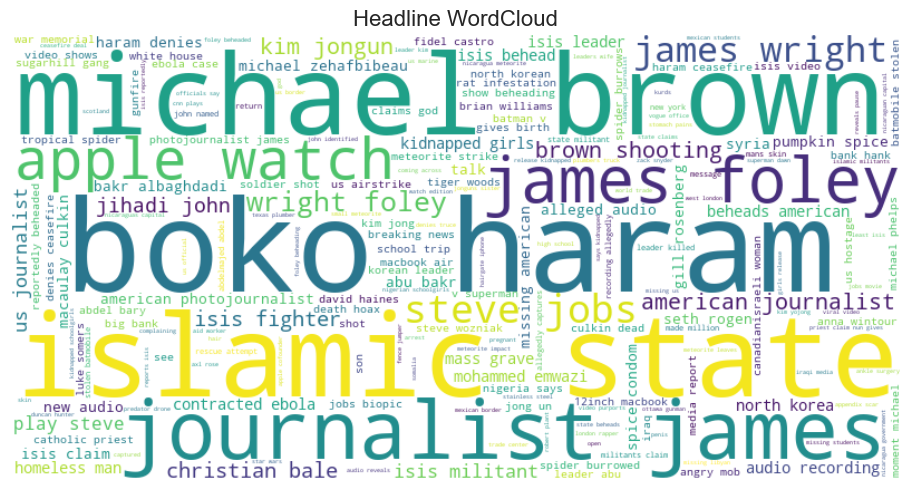

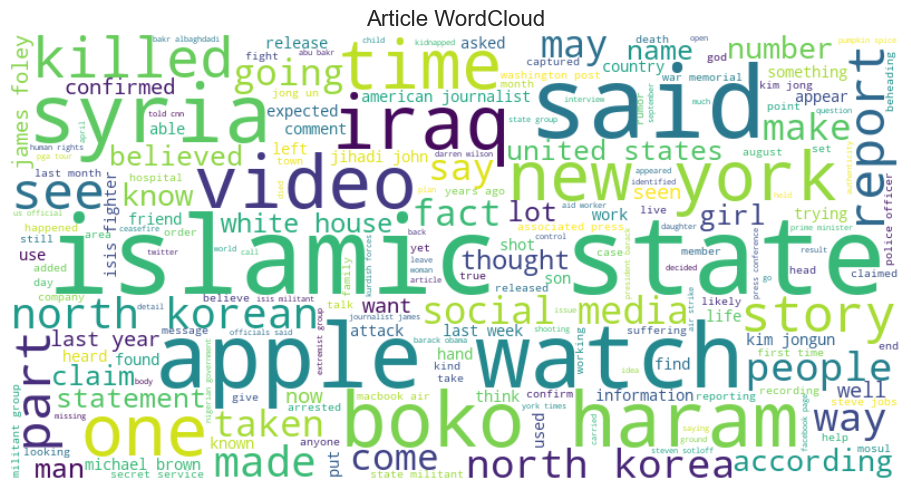

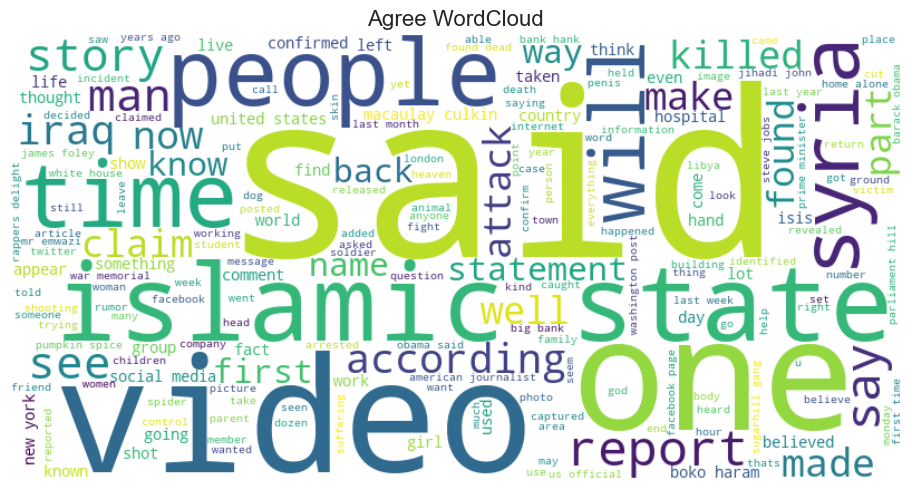

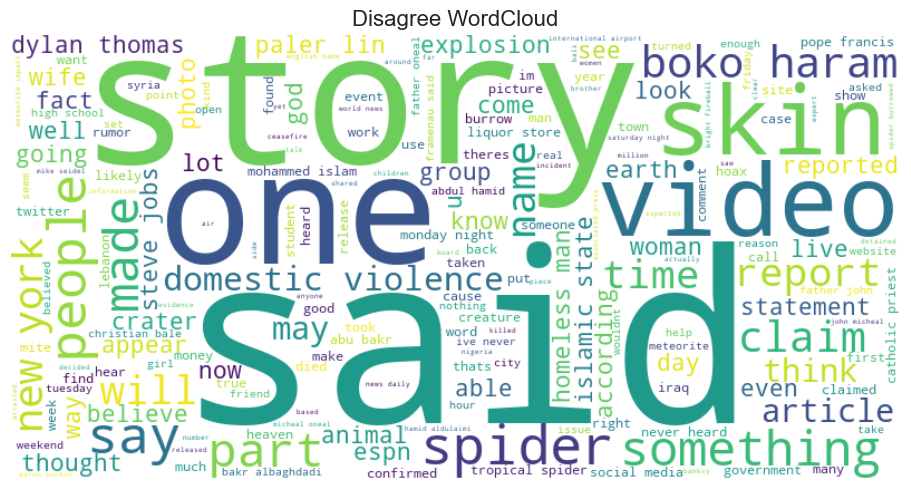

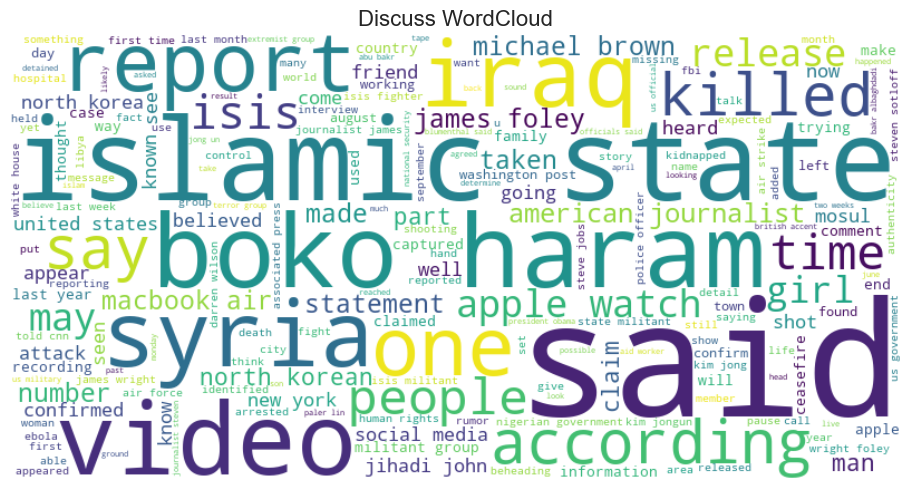

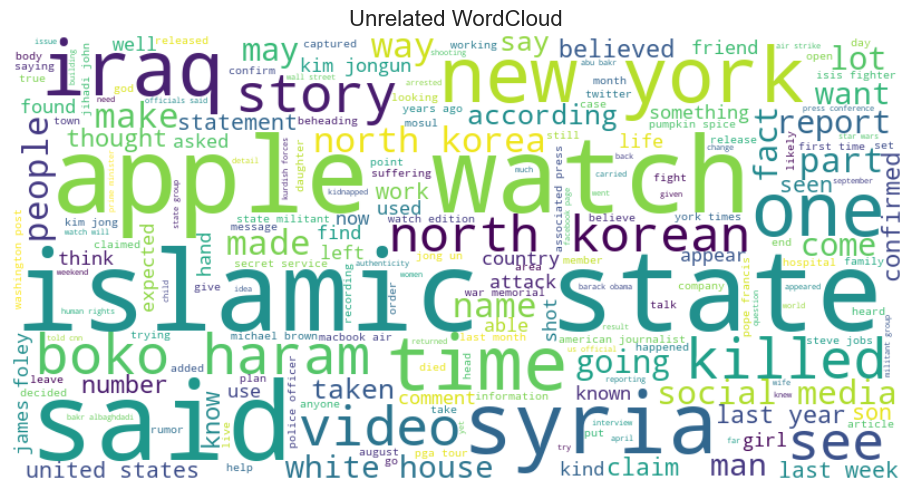

In [36]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['Clean_Headline'] = df['Headline'].apply(clean_text)
df['Clean_Article'] = df['articleBody'].apply(clean_text)

stop_words = set(STOPWORDS)

def generate_wordcloud(text, title):
    if not text.strip():
        return
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

generate_wordcloud(' '.join(df['Clean_Headline']), 'Headline WordCloud')
generate_wordcloud(' '.join(df['Clean_Article']), 'Article WordCloud')

stances = ['agree', 'disagree', 'discuss', 'unrelated']
for stance in stances:
    stance_text = ' '.join(df[df['Stance'] == stance]['Clean_Article'])
    generate_wordcloud(stance_text, f'{stance.capitalize()} WordCloud')

# Sample Inspection

Menampilkan 5 sampel acak dengan headline, stance, dan 300 karakter pertama dari article body.

In [37]:
samples = df.sample(5, random_state=42)

for index, row in samples.iterrows():
    print("-" * 80)
    print(f"Stance: {row['Stance'].upper()}")
    print(f"Headline: {row['Headline']}")
    print(f"Article (first 300 chars): {str(row['articleBody'])[:300]}...")
print("-" * 80)

--------------------------------------------------------------------------------
Stance: UNRELATED
Headline: Mum faces real-life Sophie's Choice – as she tries to sell her son to fund daughter's care
Article (first 300 chars): (Mashable) Reports that Islamic State militants in Mosul have contracted Ebola swirled though Iraqi media sources on Wednesday. World Health Organization officials said they haven’t confirmed the cases, but the organization has reached out to offer assistance.

Three outlets reported that Ebola show...
--------------------------------------------------------------------------------
Stance: UNRELATED
Headline: Dog Found Abandoned With Suitcase Filled With His Belongings
Article (first 300 chars): Fox & Friends got very excited Thursday morning over rumors, which they credited to Jordanian TV, that King Abdullah of Jordan had potentially participated in retaliatory airstrikes against ISIS after the immolation death of Jordanian pilot Muath al-Kasaesbeh.

“What a st

# Summary Statistics

Ringkasan statistik keseluruhan dataset.

In [38]:
summary_data = {
    'Metric': [
        'Total samples',
        'Unique headlines',
        'Unique bodies',
        'Duplicate rows',
        'Missing values',
        'Majority class',
        'Minority class',
        'Mean article token length',
        'Median article token length',
        'Maximum article token length',
        'Percentage above 512 tokens',
        'Percentage above 4096 tokens'
    ],
    'Value': [
        len(df),
        df['Headline'].nunique(),
        df['Body ID'].nunique(),
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        df['Stance'].value_counts().idxmax(),
        df['Stance'].value_counts().idxmin(),
        round(df['Article_Token_Count'].mean(), 2),
        round(df['Article_Token_Count'].median(), 2),
        df['Article_Token_Count'].max(),
        f"{(df['Article_Token_Count'] > 512).sum() / len(df) * 100:.2f}%",
        f"{(df['Article_Token_Count'] > 4096).sum() / len(df) * 100:.2f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Metric,Value
0,Total samples,49972
1,Unique headlines,1648
2,Unique bodies,1683
3,Duplicate rows,402
4,Missing values,0
5,Majority class,unrelated
6,Minority class,disagree
7,Mean article token length,496.36
8,Median article token length,407.0
9,Maximum article token length,6156


# Longformer Justification

Kesimpulan apakah penggunaan Longformer dapat dijustifikasi dibandingkan dengan BERT berdasarkan analisis token length.

In [39]:
print("=== Longformer Justification Summary ===")
print(f"Average article token length: {df['Article_Token_Count'].mean():.2f}")
print(f"Maximum article token length: {df['Article_Token_Count'].max()}")
print(f"Percentage of samples above 512 tokens (BERT limit): {percentages['> 512 (BERT limit)']:.2f}%")
print(f"Percentage of samples above 1024 tokens: {percentages['> 1024']:.2f}%")
print(f"Percentage of samples above 2048 tokens: {percentages['> 2048']:.2f}%")
print(f"Percentage of samples above 4096 tokens (Longformer limit): {percentages['> 4096 (Longformer limit)']:.2f}%")

print("\nConclusion:")
print("A substantial portion of the articles exceed the standard 512-token limit of BERT models.")
print("Using BERT would require truncating a significant amount of text, potentially discarding critical information necessary for accurate stance detection.")
print("Longformer is highly justified for this dataset as its 4096-token context window can accommodate the vast majority of articles entirely, allowing the model to leverage the full context.")

=== Longformer Justification Summary ===
Average article token length: 496.36
Maximum article token length: 6156
Percentage of samples above 512 tokens (BERT limit): 35.72%
Percentage of samples above 1024 tokens: 7.66%
Percentage of samples above 2048 tokens: 0.79%
Percentage of samples above 4096 tokens (Longformer limit): 0.02%

Conclusion:
A substantial portion of the articles exceed the standard 512-token limit of BERT models.
Using BERT would require truncating a significant amount of text, potentially discarding critical information necessary for accurate stance detection.
Longformer is highly justified for this dataset as its 4096-token context window can accommodate the vast majority of articles entirely, allowing the model to leverage the full context.
